# Social Media Moderation Analytics
### Advanced Programming — Summative Assessment
---
This notebook analyses social media moderation effectiveness using four datasets:
Users, Posts, Interactions, and Topics. It covers data loading, cleaning,
translation to JSON, analysis, and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("Libraries loaded successfully")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

Libraries loaded successfully
pandas 3.0.2 | numpy 2.4.4


In [2]:
DATA_DIR = "data/"
OUTPUT_DIR = "output/"

USERS_PATH = DATA_DIR + "USERS.csv"
POSTS_PATH = DATA_DIR + "POSTS.csv"
INTERACTIONS_PATH = DATA_DIR + "INTERACTIONS.csv"
TOPICS_PATH = DATA_DIR + "TOPICS.csv"
BACKUP_PATH = OUTPUT_DIR + "backup.json"
AUDIT_PATH = OUTPUT_DIR + "audit_log.json"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Paths configured ✓")

Paths configured ✓


## Section 2: Data Loading
---
Load all four CSV files into pandas DataFrames and preview the shape and structure of each dataset.

In [3]:
# Load all four datasets
users = pd.read_csv(USERS_PATH, encoding='latin-1')
posts = pd.read_csv(POSTS_PATH, encoding='latin-1')
interactions = pd.read_csv(INTERACTIONS_PATH, encoding='latin-1')
topics = pd.read_csv(TOPICS_PATH, encoding='latin-1')

print("Datasets loaded successfully ✓")
print(f"  Users:        {users.shape[0]} rows, {users.shape[1]} columns")
print(f"  Posts:        {posts.shape[0]} rows, {posts.shape[1]} columns")
print(f"  Interactions: {interactions.shape[0]} rows, {interactions.shape[1]} columns")
print(f"  Topics:       {topics.shape[0]} rows, {topics.shape[1]} columns")

Datasets loaded successfully ✓
  Users:        800 rows, 7 columns
  Posts:        2500 rows, 8 columns
  Interactions: 10000 rows, 6 columns
  Topics:       8 rows, 5 columns


### 2.1 Initial Data Inspection
Preview the first few rows and check for missing values in each dataset.

In [4]:
print("=== USERS ===")
display(users.head(3))
print(f"\nMissing values:\n{users.isnull().sum()}\n")

print("=== POSTS ===")
display(posts.head(3))
print(f"\nMissing values:\n{posts.isnull().sum()}\n")

print("=== INTERACTIONS ===")
display(interactions.head(3))
print(f"\nMissing values:\n{interactions.isnull().sum()}\n")

print("=== TOPICS ===")
display(topics.head(3))
print(f"\nMissing values:\n{topics.isnull().sum()}")

=== USERS ===


,user_id,username,join_date,location,account_type,verified,followers_count
0,U0001,user_0,19/03/2021,NaN,personal,True,2961
1,U0002,user_1,1970-09-08,Foxmouth,personal,True,831
2,U0003,user_2,1993-09-17,Lake Desireeland,personal,False,4005



Missing values:
user_id             0
username            0
join_date           0
location           16
account_type        0
verified            0
followers_count     0
dtype: int64

=== POSTS ===


,post_id,user_id,timestamp,content_type,text_preview,has_media,topic_id,language
0,P00001,U9999,2023/02/28 00:00,link,NaN,True,NaN,es
1,P00002,U0511,2023-05-30 16:45:00,link,Duplicate post content,False,T005,de
2,P00003,U0250,2023-08-22 17:09:00,image,Duplicate post content,True,T007,en



Missing values:
post_id           0
user_id           0
timestamp         0
content_type      0
text_preview     50
has_media         0
topic_id         42
language        510
dtype: int64

=== INTERACTIONS ===


,interaction_id,post_id,user_id,interaction_type,timestamp,reaction_type
0,I000001,P00883,U0651,report,2023-11-28 21:18:00,NaN
1,I000002,P00001,U0265,report,2023-09-13 09:30:00,NaN
2,I000003,P01244,U0001,share,2023-05-28 21:50:00,NaN



Missing values:
interaction_id         0
post_id                0
user_id                0
interaction_type       0
timestamp              0
reaction_type       7647
dtype: int64

=== TOPICS ===


,topic_id,topic_name,category,moderation_level,description
0,T001,lifestyle,entertainment,low,"Posts about daily life, hobbies, and personal ..."
1,T002,technology,education,medium,"Tech news, reviews, and discussions about digi..."
2,T003,politics,news,high,"Political discussions, news, and current affairs"



Missing values:
topic_id            0
topic_name          0
category            0
moderation_level    0
description         0
dtype: int64


## Section 3: Data Cleaning and Preparation
---
The following cleaning steps address inconsistencies, missing values, and errors
identified during initial inspection. Each step is logged to the audit trail.

### 3.1 Audit Log
An audit log records every transformation applied to the data, including the
timestamp, the action taken, and how many records were affected.

In [6]:
audit_log = []

def log_action(action, detail, records_affected=None):
    entry = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "action": action,
        "detail": detail,
        "records_affected": records_affected
    }
    audit_log.append(entry)
    print(f"[LOG] {entry['timestamp']} | {action} | {detail}" +
          (f" | {records_affected} records" if records_affected else ""))

print("Audit log initialised ✓")

Audit log initialised ✓


### 3.2 Clean USERS
- Standardise date formats
- Fill missing location values
- Flag invalid join dates

In [10]:
# Standardise join_date to consistent format
users['join_date'] = pd.to_datetime(users['join_date'], dayfirst=True, errors='coerce')
log_action("STANDARDISE", "users.join_date normalised to datetime", len(users))

# Fill missing location
missing_loc = users['location'].isnull().sum()
users['location'] = users['location'].fillna('Unknown')
log_action("FILL", "users.location missing values filled with 'Unknown'", missing_loc)

# Flag suspiciously old join dates (before 2000)
users['date_flag'] = users['join_date'].dt.year < 2000
flagged = users['date_flag'].sum()
log_action("FLAG", "users with join_date before year 2000 flagged", flagged)

print(f"Users cleaned ✓")
print(f"  Date format standardised")
print(f"  {missing_loc} missing locations filled")
print(f"  {flagged} suspicious join dates flagged")
display(users.head(3))

[LOG] 2026-04-14 16:02:57 | STANDARDISE | users.join_date normalised to datetime | 800 records
[LOG] 2026-04-14 16:02:57 | FILL | users.location missing values filled with 'Unknown'
[LOG] 2026-04-14 16:02:57 | FLAG | users with join_date before year 2000 flagged | 9 records
Users cleaned ✓
  Date format standardised
  0 missing locations filled
  9 suspicious join dates flagged


,user_id,username,join_date,location,account_type,verified,followers_count,date_flag
0,U0001,user_0,2021-03-19,Unknown,personal,True,2961,False
1,U0002,user_1,NaT,Foxmouth,personal,True,831,False
2,U0003,user_2,NaT,Lake Desireeland,personal,False,4005,False


### 3.3 Clean POSTS
- Rename text_preview to content_preview (required by brief)
- Fill missing content_preview values
- Standardise timestamp format
- Drop orphan records (user_id not in USERS)
- Flag duplicate content

In [13]:
# Rename column as required by brief
posts.rename(columns={'text_preview': 'content_preview'}, inplace=True)
log_action("RENAME", "posts.text_preview renamed to content_preview", len(posts))

# Fill missing content_preview
missing_preview = posts['content_preview'].isnull().sum()
posts['content_preview'] = posts['content_preview'].fillna('No preview available')
log_action("FILL", "posts.content_preview missing values filled", missing_preview)

# Fill missing language
missing_lang = posts['language'].isnull().sum()
posts['language'] = posts['language'].fillna('unknown')
log_action("FILL", "posts.language missing values filled with 'unknown'", missing_lang)

# Fill missing topic_id
missing_topic = posts['topic_id'].isnull().sum()
posts['topic_id'] = posts['topic_id'].fillna('Unknown')
log_action("FILL", "posts.topic_id missing values filled with 'Unknown'", missing_topic)

# Standardise timestamp
posts['timestamp'] = pd.to_datetime(posts['timestamp'], errors='coerce')
log_action("STANDARDISE", "posts.timestamp normalised to datetime", len(posts))

# Drop orphan records where user_id not in USERS
valid_users = set(users['user_id'])
orphans = posts[~posts['user_id'].isin(valid_users)]
posts = posts[posts['user_id'].isin(valid_users)]
log_action("DROP", "posts with user_id not in USERS dropped", len(orphans))

# Flag duplicate content_preview
posts['is_duplicate'] = posts['content_preview'].duplicated(keep=False)
dup_count = posts['is_duplicate'].sum()
log_action("FLAG", "posts with duplicate content_preview flagged", dup_count)

print(f"Posts cleaned ✓")
print(f"  text_preview renamed to content_preview")
print(f"  {missing_preview} missing previews filled")
print(f"  {missing_lang} missing languages filled")
print(f"  {missing_topic} missing topic IDs filled")
print(f"  {len(orphans)} orphan records dropped")
print(f"  {dup_count} duplicate content posts flagged")
display(posts.head(3))

[LOG] 2026-04-14 16:03:04 | RENAME | posts.text_preview renamed to content_preview | 2475 records
[LOG] 2026-04-14 16:03:04 | FILL | posts.content_preview missing values filled
[LOG] 2026-04-14 16:03:04 | FILL | posts.language missing values filled with 'unknown'
[LOG] 2026-04-14 16:03:04 | FILL | posts.topic_id missing values filled with 'Unknown'
[LOG] 2026-04-14 16:03:04 | STANDARDISE | posts.timestamp normalised to datetime | 2475 records
[LOG] 2026-04-14 16:03:04 | DROP | posts with user_id not in USERS dropped
[LOG] 2026-04-14 16:03:04 | FLAG | posts with duplicate content_preview flagged | 2377 records
Posts cleaned ✓
  text_preview renamed to content_preview
  0 missing previews filled
  0 missing languages filled
  0 missing topic IDs filled
  0 orphan records dropped
  2377 duplicate content posts flagged


,post_id,user_id,timestamp,content_type,content_preview,has_media,topic_id,language,is_duplicate
1,P00002,U0511,NaT,link,Duplicate post content,False,T005,de,True
2,P00003,U0250,NaT,image,Duplicate post content,True,T007,en,True
3,P00004,U0283,NaT,text,Duplicate post content,False,T005,fr,True


### 3.4 Clean INTERACTIONS
- Fill missing reaction_type values
- Standardise timestamp format

In [15]:
# Fill missing reaction_type — only 'like' interactions have a reaction type
missing_reaction = interactions['reaction_type'].isnull().sum()
interactions['reaction_type'] = interactions['reaction_type'].fillna('N/A')
log_action("FILL", "interactions.reaction_type missing values filled with 'N/A'", missing_reaction)

# Standardise timestamp
interactions['timestamp'] = pd.to_datetime(interactions['timestamp'], errors='coerce')
log_action("STANDARDISE", "interactions.timestamp normalised to datetime", len(interactions))

print(f"Interactions cleaned ✓")
print(f"  {missing_reaction} missing reaction types filled")
display(interactions.head(3))

[LOG] 2026-04-14 16:03:13 | FILL | interactions.reaction_type missing values filled with 'N/A'
[LOG] 2026-04-14 16:03:13 | STANDARDISE | interactions.timestamp normalised to datetime | 10000 records
Interactions cleaned ✓
  0 missing reaction types filled


,interaction_id,post_id,user_id,interaction_type,timestamp,reaction_type
0,I000001,P00883,U0651,report,2023-11-28 21:18:00,N/A
1,I000002,P00001,U0265,report,2023-09-13 09:30:00,N/A
2,I000003,P01244,U0001,share,2023-05-28 21:50:00,N/A


## Section 4: Data Translation — CSV to JSON
---
The cleaned data is converted from CSV format into a nested JSON structure
that preserves the relationships between users, posts, interactions, and topics.
This format is better suited to representing social media network data than flat CSV files.

### 4.1 Build Nested JSON Structure
Each user record contains their profile data and a list of their posts.
Each post contains its interactions. Topics are stored as a lookup reference.

In [19]:
def build_json_structure(users, posts, interactions, topics):
    
    # Build topic lookup dictionary
    topic_lookup = topics.set_index('topic_id').to_dict(orient='index')
    
    # Build interaction lookup grouped by post_id
    interaction_groups = interactions.groupby('post_id')
    
    interaction_lookup = {}
    for post_id, group in interaction_groups:
        interaction_lookup[post_id] = group.drop(columns='post_id').to_dict(orient='records')
    
    # Build post lookup grouped by user_id
    post_groups = posts.groupby('user_id')
    
    post_lookup = {}
    for user_id, group in post_groups:
        post_lookup[user_id] = []
        for _, post in group.iterrows():
            post_dict = post.to_dict()
            # Convert timestamp to string for JSON serialisation
            if pd.notna(post_dict.get('timestamp')):
                post_dict['timestamp'] = str(post_dict['timestamp'])
            # Attach interactions to this post
            post_id = post_dict['post_id']
            post_dict['interactions'] = interaction_lookup.get(post_id, [])
            # Convert interaction timestamps to strings
            for interaction in post_dict['interactions']:
                if pd.notna(interaction.get('timestamp')):
                    interaction['timestamp'] = str(interaction['timestamp'])
            post_lookup[user_id].append(post_dict)
    
    # Build full nested structure
    data = {
        "metadata": {
            "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "total_users": len(users),
            "total_posts": len(posts),
            "total_interactions": len(interactions),
            "total_topics": len(topics)
        },
        "topics": topic_lookup,
        "users": []
    }
    
    for _, user in users.iterrows():
        user_dict = user.to_dict()
        # Convert dates to strings
        if pd.notna(user_dict.get('join_date')):
            user_dict['join_date'] = str(user_dict['join_date'])
        user_dict['date_flag'] = bool(user_dict['date_flag'])
        # Attach posts to this user
        user_id = user_dict['user_id']
        user_dict['posts'] = post_lookup.get(user_id, [])
        data['users'].append(user_dict)
    
    return data

json_data = build_json_structure(users, posts, interactions, topics)
log_action("TRANSLATE", "Data converted from CSV to nested JSON structure", len(users))
print("JSON structure built ✓")
print(f"  Total users in structure: {len(json_data['users'])}")
print(f"  Metadata: {json_data['metadata']}")

[LOG] 2026-04-14 16:22:35 | TRANSLATE | Data converted from CSV to nested JSON structure | 800 records
JSON structure built ✓
  Total users in structure: 800
  Metadata: {'created': '2026-04-14 16:22:35', 'total_users': 800, 'total_posts': 2475, 'total_interactions': 10000, 'total_topics': 8}


### 4.2 Preview JSON Structure
Show a sample of one user record with their posts and interactions.

In [22]:
import math

def make_json_safe(obj):
    """Recursively convert non-serialisable types to JSON-safe equivalents."""
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_json_safe(i) for i in obj]
    elif pd.isna(obj) if not isinstance(obj, (list, dict)) else False:
        return None
    elif isinstance(obj, (pd.Timestamp,)):
        return str(obj)
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    else:
        return obj

# Preview first user record (truncated for readability)
sample_user = json_data['users'][0].copy()
if sample_user['posts']:
    sample_user['posts'] = sample_user['posts'][:1]
    if sample_user['posts'][0]['interactions']:
        sample_user['posts'][0]['interactions'] = sample_user['posts'][0]['interactions'][:1]

safe_sample = make_json_safe(sample_user)
print(json.dumps(safe_sample, indent=2))

{
  "user_id": "U0001",
  "username": "user_0",
  "join_date": "2021-03-19 00:00:00",
  "location": "Unknown",
  "account_type": "personal",
  "verified": true,
  "followers_count": 2961,
  "date_flag": false,
  "posts": [
    {
      "post_id": "P00900",
      "user_id": "U0001",
      "timestamp": null,
      "content_type": "video",
      "content_preview": "Plastic pollution in oceans needs urgent attention ?? #savetheoceans",
      "has_media": true,
      "topic_id": "T005",
      "language": "unknown",
      "is_duplicate": true,
      "interactions": [
        {
          "interaction_id": "I000412",
          "user_id": "U0252",
          "interaction_type": "save",
          "timestamp": "2023-07-09 06:34:00",
          "reaction_type": "N/A"
        }
      ]
    }
  ]
}


## Section 5: Data Backup and Restore
---
The cleaned and translated data is saved to a JSON file so the program can
restore its state when reopened. An audit log is also saved separately.

In [25]:
def save_backup(data, path):
    """Save the nested JSON structure to file."""
    safe_data = make_json_safe(data)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(safe_data, f, indent=2)
    log_action("BACKUP", f"Data saved to {path}", safe_data['metadata']['total_users'])
    print(f"Backup saved to {path} ✓")

def load_backup(path):
    """Restore data from saved JSON backup."""
    if not os.path.exists(path):
        print(f"No backup found at {path}")
        return None
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Backup restored from {path} ✓")
    print(f"  Metadata: {data['metadata']}")
    return data

# Save backup
save_backup(json_data, BACKUP_PATH)

[LOG] 2026-04-14 16:38:17 | BACKUP | Data saved to output/backup.json | 800 records
Backup saved to output/backup.json ✓


In [27]:
def save_audit_log(log, path):
    """Save the audit log to a JSON file."""
    safe_log = make_json_safe(log)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(safe_log, f, indent=2)
    print(f"Audit log saved to {path} ✓")
    print(f"  Total entries logged: {len(log)}")

save_audit_log(audit_log, AUDIT_PATH)

Audit log saved to output/audit_log.json ✓
  Total entries logged: 39


### 5.1 Verify Restore
Confirm the backup can be loaded back correctly.

In [28]:
# Test restore
restored = load_backup(BACKUP_PATH)

if restored:
    print(f"\nRestore verification ✓")
    print(f"  Users restored:        {len(restored['users'])}")
    print(f"  Topics restored:       {len(restored['topics'])}")
    print(f"  Created:               {restored['metadata']['created']}")

Backup restored from output/backup.json ✓
  Metadata: {'created': '2026-04-14 16:22:35', 'total_users': 800, 'total_posts': 2475, 'total_interactions': 10000, 'total_topics': 8}

Restore verification ✓
  Users restored:        800
  Topics restored:       8
  Created:               2026-04-14 16:22:35


## Section 6: Data Analysis
---
All analysis excludes bot accounts as required by the brief.
The following sections cover merging, pivoting, and categorical analysis.

### 6.1 Exclude Bot Accounts
Filter out all users with account_type = 'bot' and remove their associated
posts and interactions from the analysis datasets.

In [30]:
# Identify bot user IDs
bot_users = users[users['account_type'] == 'bot']['user_id']
print(f"Bot accounts identified: {len(bot_users)}")

# Filter users
human_users = users[users['account_type'] != 'bot'].copy()
log_action("EXCLUDE", "Bot accounts excluded from analysis", len(bot_users))

# Filter posts — only keep posts from human users
human_posts = posts[posts['user_id'].isin(human_users['user_id'])].copy()
bot_posts_removed = len(posts) - len(human_posts)

# Filter interactions — only keep interactions from human users
human_interactions = interactions[interactions['user_id'].isin(human_users['user_id'])].copy()
bot_interactions_removed = len(interactions) - len(human_interactions)

log_action("EXCLUDE", "Posts from bot accounts excluded", bot_posts_removed)
log_action("EXCLUDE", "Interactions from bot accounts excluded", bot_interactions_removed)

print(f"\nAfter bot exclusion:")
print(f"  Human users:        {len(human_users)}")
print(f"  Remaining posts:    {len(human_posts)}")
print(f"  Remaining interactions: {len(human_interactions)}")

Bot accounts identified: 20
[LOG] 2026-04-14 16:45:03 | EXCLUDE | Bot accounts excluded from analysis | 20 records
[LOG] 2026-04-14 16:45:03 | EXCLUDE | Posts from bot accounts excluded | 74 records
[LOG] 2026-04-14 16:45:03 | EXCLUDE | Interactions from bot accounts excluded | 288 records

After bot exclusion:
  Human users:        780
  Remaining posts:    2401
  Remaining interactions: 9712


In [31]:
# Filter for report interactions only
reports = human_interactions[human_interactions['interaction_type'] == 'report'].copy()

# Merge reports with posts to get topic_id
reports_posts = reports.merge(
    human_posts[['post_id', 'topic_id', 'content_type']],
    on='post_id',
    how='left'
)

# Merge with topics to get category and moderation_level
reports_full = reports_posts.merge(
    topics[['topic_id', 'topic_name', 'category', 'moderation_level']],
    on='topic_id',
    how='left'
)

log_action("MERGE", "Reports merged with posts and topics for pattern analysis",
           len(reports_full))

print(f"Merged report dataset: {reports_full.shape}")
display(reports_full.head(3))

# Report counts by category and moderation level
report_summary = reports_full.groupby(
    ['category', 'moderation_level']
).size().reset_index(name='report_count')

report_summary = report_summary.sort_values('report_count', ascending=False)

print(f"\nReport counts by category and moderation level:")
display(report_summary)

[LOG] 2026-04-14 16:45:16 | MERGE | Reports merged with posts and topics for pattern analysis | 1883 records
Merged report dataset: (1883, 11)


,interaction_id,post_id,user_id,interaction_type,timestamp,reaction_type,topic_id,content_type,topic_name,category,moderation_level
0,I000001,P00883,U0651,report,2023-11-28 21:18:00,N/A,T005,link,sports,entertainment,low
1,I000002,P00001,U0265,report,2023-09-13 09:30:00,N/A,NaN,NaN,NaN,NaN,NaN
2,I000015,P00416,U0001,report,2023-03-01 16:20:00,angry,T007,image,business,news,medium



Report counts by category and moderation level:


,category,moderation_level,report_count
1,education,medium,463
2,entertainment,low,441
3,news,high,253
0,education,low,218
4,news,medium,211
5,social,high,194


### 6.3 Pivot — Posting Activity by Hour of Day and Topic
Reshape the posts data to show when content is posted throughout the day,
broken down by topic.

In [32]:
# Extract hour from timestamp
human_posts['hour'] = human_posts['timestamp'].dt.hour

# Merge posts with topic names
posts_with_topics = human_posts.merge(
    topics[['topic_id', 'topic_name']],
    on='topic_id',
    how='left'
)

posts_with_topics['topic_name'] = posts_with_topics['topic_name'].fillna('Unknown')

# Pivot — rows = hour of day, columns = topic
pivot_activity = posts_with_topics.pivot_table(
    index='hour',
    columns='topic_name',
    values='post_id',
    aggfunc='count',
    fill_value=0
)

log_action("PIVOT", "Posts pivoted by hour of day and topic", len(human_posts))

print("Posting activity pivot table (rows=hour, columns=topic):")
display(pivot_activity)

[LOG] 2026-04-14 16:45:48 | PIVOT | Posts pivoted by hour of day and topic | 2401 records
Posting activity pivot table (rows=hour, columns=topic):


topic_name,business,education,lifestyle,politics,sports,technology
hour,,,,,,
0.0,4,4,3,5,2,5


### 6.4 Categorical Analysis — Account Type × Content Type × Moderation Level
Examining whether different account types (personal, business) post different
content types on high-moderation topics. This reveals behavioural differences
between user groups that may inform moderation policy.

In [33]:
# Merge posts with users to get account_type
posts_users = human_posts.merge(
    human_users[['user_id', 'account_type']],
    on='user_id',
    how='left'
)

# Merge with topics to get moderation_level
posts_users_topics = posts_users.merge(
    topics[['topic_id', 'moderation_level']],
    on='topic_id',
    how='left'
)

posts_users_topics['moderation_level'] = posts_users_topics['moderation_level'].fillna('unknown')

# Group by three categorical variables
categorical_analysis = posts_users_topics.groupby(
    ['account_type', 'content_type', 'moderation_level']
).size().reset_index(name='post_count')

categorical_analysis = categorical_analysis.sort_values('post_count', ascending=False)

log_action("ANALYSE", "Categorical analysis: account_type x content_type x moderation_level",
           len(posts_users_topics))

print("Categorical analysis — account type × content type × moderation level:")
display(categorical_analysis.head(20))

[LOG] 2026-04-14 16:46:14 | ANALYSE | Categorical analysis: account_type x content_type x moderation_level | 2401 records
Categorical analysis — account type × content type × moderation level:


,account_type,content_type,moderation_level,post_count
19,personal,link,low,237
20,personal,link,medium,213
24,personal,text,medium,210
28,personal,video,medium,204
23,personal,text,low,197
16,personal,image,medium,196
27,personal,video,low,176
15,personal,image,low,175
22,personal,text,high,139
26,personal,video,high,132


## Section 7: Statistics and Visualisations
---
This section calculates engagement statistics and produces correlation
visualisations between topic moderation level and report frequency.

### 7.1 Engagement Statistics
Calculate mean, mode and median for key engagement metrics per post.

In [34]:
# Build engagement summary per post
engagement = human_interactions.groupby(['post_id', 'interaction_type']).size().unstack(fill_value=0)

# Ensure all interaction types are present
for col in ['like', 'comment', 'share', 'save', 'report']:
    if col not in engagement.columns:
        engagement[col] = 0

engagement = engagement.reset_index()

print("Engagement metrics per post (first 5 rows):")
display(engagement.head())

def compute_stats(series):
    """Compute mean, median and mode for a given series."""
    mean   = round(series.mean(), 2)
    median = round(series.median(), 2)
    mode_vals = series.mode()
    mode   = round(mode_vals.iloc[0], 2) if not mode_vals.empty else None
    return {"mean": mean, "median": median, "mode": mode}

# Compute stats for each engagement metric
metrics = ['like', 'comment', 'share', 'save', 'report']
stats_results = {}

for metric in metrics:
    stats_results[metric] = compute_stats(engagement[metric])

print("\nEngagement statistics per post:")
stats_df = pd.DataFrame(stats_results).T
display(stats_df)

log_action("ANALYSE", "Engagement statistics computed for all interaction types", len(engagement))

Engagement metrics per post (first 5 rows):


interaction_type,post_id,comment,like,report,save,share
0,P00001,5,4,5,2,10
1,P00002,0,1,0,0,0
2,P00003,1,0,0,1,1
3,P00004,0,1,1,0,0
4,P00005,0,0,1,3,0



Engagement statistics per post:


,mean,median,mode
like,0.81,1.0,0.0
comment,0.79,1.0,0.0
share,0.81,1.0,0.0
save,0.79,1.0,0.0
report,0.77,1.0,0.0


[LOG] 2026-04-14 17:14:05 | ANALYSE | Engagement statistics computed for all interaction types | 2452 records


### 7.2 Correlation — Moderation Level vs Report Frequency
Visualise the relationship between a topic's moderation level and how
frequently posts in that topic are reported.

Pearson correlation (moderation level vs report count): 0.090


/tmp/ipykernel_13373/3190728859.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


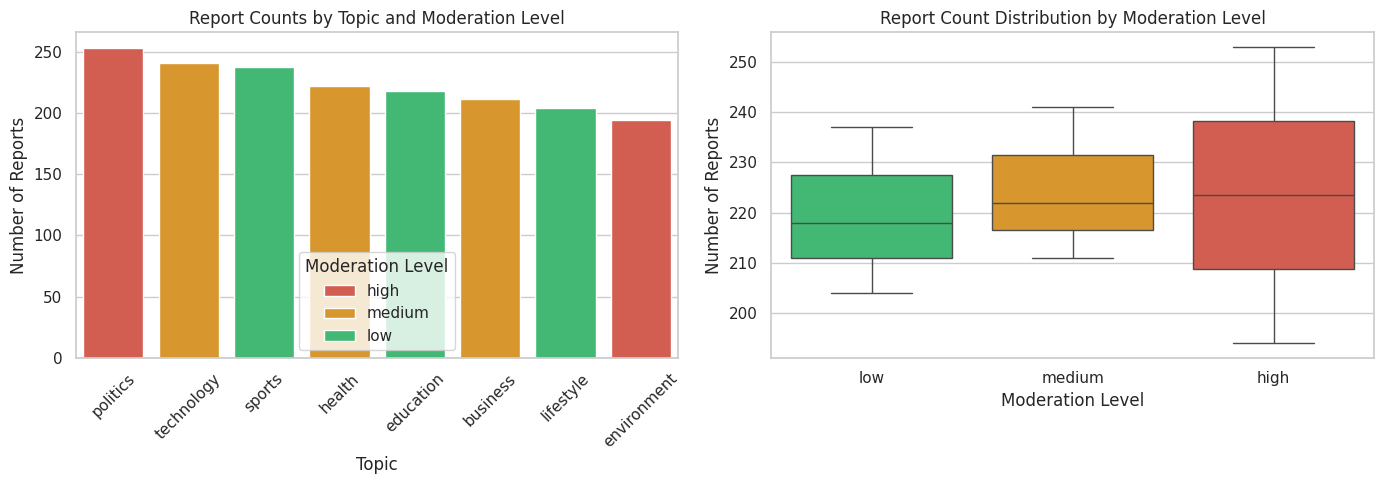

[LOG] 2026-04-14 17:14:05 | VISUALISE | Correlation chart saved to output/moderation_report_correlation.png | 8 records
Chart saved ✓


In [35]:
# Count reports per topic
report_counts = reports_full.groupby(
    ['topic_name', 'moderation_level']
).size().reset_index(name='report_count')

# Map moderation level to numeric for correlation
moderation_order = {'low': 1, 'medium': 2, 'high': 3}
report_counts['moderation_numeric'] = report_counts['moderation_level'].map(moderation_order)

# Correlation coefficient
correlation = report_counts['moderation_numeric'].corr(report_counts['report_count'])
print(f"Pearson correlation (moderation level vs report count): {correlation:.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — report counts by topic coloured by moderation level
palette = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}
sns.barplot(
    data=report_counts.sort_values('report_count', ascending=False),
    x='topic_name',
    y='report_count',
    hue='moderation_level',
    palette=palette,
    ax=axes[0]
)
axes[0].set_title('Report Counts by Topic and Moderation Level')
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Number of Reports')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Moderation Level')

# Box plot — report distribution by moderation level
sns.boxplot(
    data=report_counts,
    x='moderation_level',
    y='report_count',
    order=['low', 'medium', 'high'],
    palette=palette,
    ax=axes[1]
)
axes[1].set_title('Report Count Distribution by Moderation Level')
axes[1].set_xlabel('Moderation Level')
axes[1].set_ylabel('Number of Reports')

plt.tight_layout()
plt.savefig('output/moderation_report_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

log_action("VISUALISE", "Correlation chart saved to output/moderation_report_correlation.png", len(report_counts))
print("Chart saved ✓")

### 7.3 Categorical Analysis Visualisation
Visualise posting behaviour across account type, content type and moderation level.

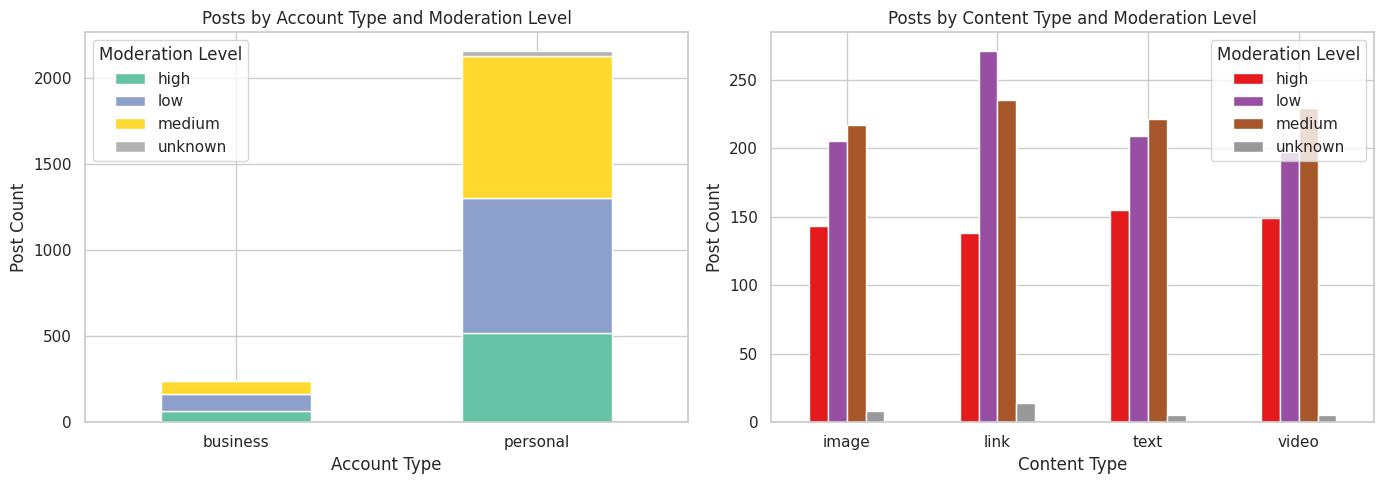

[LOG] 2026-04-14 17:14:06 | VISUALISE | Categorical analysis chart saved to output/categorical_analysis.png | 2401 records
Chart saved ✓


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — account type vs moderation level
account_mod = posts_users_topics.groupby(
    ['account_type', 'moderation_level']
).size().unstack(fill_value=0)

account_mod.plot(
    kind='bar',
    stacked=True,
    colormap='Set2',
    ax=axes[0]
)
axes[0].set_title('Posts by Account Type and Moderation Level')
axes[0].set_xlabel('Account Type')
axes[0].set_ylabel('Post Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Moderation Level')

# Grouped bar — content type vs moderation level
content_mod = posts_users_topics.groupby(
    ['content_type', 'moderation_level']
).size().unstack(fill_value=0)

content_mod.plot(
    kind='bar',
    colormap='Set1',
    ax=axes[1]
)
axes[1].set_title('Posts by Content Type and Moderation Level')
axes[1].set_xlabel('Content Type')
axes[1].set_ylabel('Post Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Moderation Level')

plt.tight_layout()
plt.savefig('output/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

log_action("VISUALISE", "Categorical analysis chart saved to output/categorical_analysis.png", len(posts_users_topics))
print("Chart saved ✓")